In [1]:
import numpy as np

**Module** is an abstract class which defines fundamental methods necessary for a training a neural network. You do not need to change anything here, just read the comments.

In [2]:
class Module(object):
    """
    Basically, you can think of a module as of a something (black box)
    which can process `input` data and produce `ouput` data.
    This is like applying a function which is called `forward`:

        output = module.forward(input)

    The module should be able to perform a backward pass: to differentiate the `forward` function.
    More, it should be able to differentiate it if is a part of chain (chain rule).
    The latter implies there is a gradient from previous step of a chain rule.

        gradInput = module.backward(input, gradOutput)
    """
    def __init__ (self):
        self.output = None
        self.gradInput = None
        self.training = True

    def forward(self, input):
        """
        Takes an input object, and computes the corresponding output of the module.
        """
        return self.updateOutput(input)

    def backward(self,input, gradOutput):
        """
        Performs a backpropagation step through the module, with respect to the given input.

        This includes
         - computing a gradient w.r.t. `input` (is needed for further backprop),
         - computing a gradient w.r.t. parameters (to update parameters while optimizing).
        """
        self.updateGradInput(input, gradOutput)
        self.accGradParameters(input, gradOutput)
        return self.gradInput


    def updateOutput(self, input):
        """
        Computes the output using the current parameter set of the class and input.
        This function returns the result which is stored in the `output` field.

        Make sure to both store the data in `output` field and return it.
        """

        # The easiest case:

        # self.output = input
        # return self.output

        pass

    def updateGradInput(self, input, gradOutput):
        """
        Computing the gradient of the module with respect to its own input.
        This is returned in `gradInput`. Also, the `gradInput` state variable is updated accordingly.

        The shape of `gradInput` is always the same as the shape of `input`.

        Make sure to both store the gradients in `gradInput` field and return it.
        """

        # The easiest case:

        # self.gradInput = gradOutput
        # return self.gradInput

        pass

    def accGradParameters(self, input, gradOutput):
        """
        Computing the gradient of the module with respect to its own parameters.
        No need to override if module has no parameters (e.g. ReLU).
        """
        pass

    def zeroGradParameters(self):
        """
        Zeroes `gradParams` variable if the module has params.
        """
        pass

    def getParameters(self):
        """
        Returns a list with its parameters.
        If the module does not have parameters return empty list.
        """
        return []

    def getGradParameters(self):
        """
        Returns a list with gradients with respect to its parameters.
        If the module does not have parameters return empty list.
        """
        return []

    def train(self):
        """
        Sets training mode for the module.
        Training and testing behaviour differs for Dropout, BatchNorm.
        """
        self.training = True

    def evaluate(self):
        """
        Sets evaluation mode for the module.
        Training and testing behaviour differs for Dropout, BatchNorm.
        """
        self.training = False

    def __repr__(self):
        """
        Pretty printing. Should be overrided in every module if you want
        to have readable description.
        """
        return "Module"

# Sequential container

**Define** a forward and backward pass procedures.

In [3]:
class Sequential(Module):
    """
    This class implements a container, which processes `input` data sequentially.

    `input` is processed by each module (layer) in self.modules consecutively.
    The resulting array is called `output`.
    """

    def __init__(self):
        super(Sequential, self).__init__()
        self.modules = []

    def add(self, module):
        """
        Adds a module to the container.
        """
        self.modules.append(module)

    def updateOutput(self, input):
        """
        Basic workflow of FORWARD PASS:

            y_0    = module[0].forward(input)
            y_1    = module[1].forward(y_0)
            ...
            output = module[n-1].forward(y_{n-2})

        Just write a little loop.
        """

        self._forward_inputs = [input]
        current = input

        for module in self.modules:
            current = module.forward(current)
            self._forward_inputs.append(current)

        self.output = current
        return self.output

    def backward(self, input, gradOutput):
        """
        Workflow of BACKWARD PASS:

            g_{n-1} = module[n-1].backward(y_{n-2}, gradOutput)
            g_{n-2} = module[n-2].backward(y_{n-3}, g_{n-1})
            ...
            g_1 = module[1].backward(y_0, g_2)
            gradInput = module[0].backward(input, g_1)

        !!!

        To each module you need to provide the input the module saw during forward pass.
        It is used while computing gradients.

        Make sure that the input for `i-th` layer is the output of `module[i]`
        (just the same input as in forward pass) and NOT `input` to this Sequential module.

        !!!
        """

        grad = gradOutput

        for i in range(len(self.modules) - 1, -1, -1):
            grad = self.modules[i].backward(self._forward_inputs[i], grad)

        self.gradInput = grad
        return self.gradInput

    def zeroGradParameters(self):
        for module in self.modules:
            module.zeroGradParameters()

    def getParameters(self):
        """
        Should gather all parameters in a list.
        """
        return [x.getParameters() for x in self.modules]

    def getGradParameters(self):
        """
        Should gather all gradients w.r.t parameters in a list.
        """
        return [x.getGradParameters() for x in self.modules]

    def __repr__(self):
        return "".join([str(x) + '\n' for x in self.modules])

    def __getitem__(self, x):
        return self.modules.__getitem__(x)

    def train(self):
        """
        Propagates training parameter through all modules
        """
        self.training = True
        for module in self.modules:
            module.train()

    def evaluate(self):
        """
        Propagates training parameter through all modules
        """
        self.training = False
        for module in self.modules:
            module.evaluate()

# Layers

## 1 (0.2). Linear transform layer
Also known as dense layer, fully-connected layer, FC-layer, InnerProductLayer (in caffe), affine transform
- input:   **`batch_size x n_feats1`**
- output: **`batch_size x n_feats2`**

In [4]:
class Linear(Module):
    """
    A module which applies a linear transformation
    A common name is fully-connected layer, InnerProductLayer in caffe.

    The module should work with 2D input of shape (n_samples, n_feature).
    """
    def __init__(self, n_in, n_out):
        super(Linear, self).__init__()

        # This is a nice initialization
        stdv = 1./np.sqrt(n_in)
        self.W = np.random.uniform(-stdv, stdv, size = (n_out, n_in))
        self.b = np.random.uniform(-stdv, stdv, size = n_out)

        self.gradW = np.zeros_like(self.W)
        self.gradb = np.zeros_like(self.b)

    def updateOutput(self, input):
        self.input = input
        self.output = input @ self.W.T + self.b
        return self.output

    def updateGradInput(self, input, gradOutput):
        self.gradInput = gradOutput @ self.W
        return self.gradInput

    def accGradParameters(self, input, gradOutput):
        self.gradW = gradOutput.T @ input  # размер (n_out, n_in)
        self.gradb = np.sum(gradOutput, axis=0)

    def zeroGradParameters(self):
        self.gradW.fill(0)
        self.gradb.fill(0)

    def getParameters(self):
        return [self.W, self.b]

    def getGradParameters(self):
        return [self.gradW, self.gradb]

    def __repr__(self):
        s = self.W.shape
        q = 'Linear %d -> %d' %(s[1],s[0])
        return q

## 2. (0.2) SoftMax
- input:   **`batch_size x n_feats`**
- output: **`batch_size x n_feats`**

$\text{softmax}(x)_i = \frac{\exp x_i} {\sum_j \exp x_j}$

Recall that $\text{softmax}(x) == \text{softmax}(x - \text{const})$. It makes possible to avoid computing exp() from large argument.

In [5]:
class SoftMax(Module):
    def __init__(self):
         super(SoftMax, self).__init__()

    def updateOutput(self, input):
        # start with normalization for numerical stability
        # вычитаем max для стабильности чисел: softmax(x) = softmax(x - max(x), затем берем exp от нормализованных значений
        shifted = np.subtract(input, input.max(axis=1, keepdims=True))
        exp_shifted = np.exp(shifted)

        sum_exp = np.sum(exp_shifted, axis=1, keepdims=True)
        self.output = exp_shifted / sum_exp #вычисляем по формуле
        return self.output

    def updateGradInput(self, input, gradOutput):
        # вычислим ∂L/∂x = output * (gradOutput - sum(output * gradOutput))
        s = self.output
        dot = np.sum(s * gradOutput, axis=1, keepdims=True)
        self.gradInput = s * (gradOutput - dot)
        return self.gradInput

    def __repr__(self):
        return "SoftMax"

## 3. (0.2) LogSoftMax
- input:   **`batch_size x n_feats`**
- output: **`batch_size x n_feats`**

$\text{logsoftmax}(x)_i = \log\text{softmax}(x)_i = x_i - \log {\sum_j \exp x_j}$

The main goal of this layer is to be used in computation of log-likelihood loss.

In [6]:
class LogSoftMax(Module):
    def __init__(self):
         super(LogSoftMax, self).__init__()

    def updateOutput(self, input):
        # start with normalization for numerical stability
        shifted = np.subtract(input, input.max(axis=1, keepdims=True))
        exp_shifted = np.exp(shifted)
        sum_exp = np.sum(exp_shifted, axis=1, keepdims=True)
        log_sum_exp = np.log(sum_exp)
        self.output = shifted - log_sum_exp
        return self.output

    def updateGradInput(self, input, gradOutput):
        log_s = self.output
        softmax_output = np.exp(log_s)
        sum_grad = np.sum(gradOutput, axis=1, keepdims=True)
        self.gradInput = gradOutput - softmax_output * sum_grad
        return self.gradInput

    def __repr__(self):
        return "LogSoftMax"

## 4. (0.3) Batch normalization
One of the most significant recent ideas that impacted NNs a lot is [**Batch normalization**](http://arxiv.org/abs/1502.03167). The idea is simple, yet effective: the features should be whitened ($mean = 0$, $std = 1$) all the way through NN. This improves the convergence for deep models letting it train them for days but not weeks. **You are** to implement the first part of the layer: features normalization. The second part (`ChannelwiseScaling` layer) is implemented below.

- input:   **`batch_size x n_feats`**
- output: **`batch_size x n_feats`**

The layer should work as follows. While training (`self.training == True`) it transforms input as $$y = \frac{x - \mu}  {\sqrt{\sigma + \epsilon}}$$
where $\mu$ and $\sigma$ - mean and variance of feature values in **batch** and $\epsilon$ is just a small number for numericall stability. Also during training, layer should maintain exponential moving average values for mean and variance:
```
    self.moving_mean = self.moving_mean * alpha + batch_mean * (1 - alpha)
    self.moving_variance = self.moving_variance * alpha + batch_variance * (1 - alpha)
```
During testing (`self.training == False`) the layer normalizes input using moving_mean and moving_variance.

Note that decomposition of batch normalization on normalization itself and channelwise scaling here is just a common **implementation** choice. In general "batch normalization" always assumes normalization + scaling.

In [7]:
class BatchNormalization(Module):
    EPS = 1e-3
    def __init__(self, alpha = 0.):
        super(BatchNormalization, self).__init__()
        self.alpha = alpha
        self.moving_mean = None
        self.moving_variance = None

    def updateOutput(self, input):
        self.input_shape = input.shape

        if input.ndim == 4:
            N, C, H, W = input.shape
            self._orig_shape = (N, C, H, W)
            input_reshaped = input.transpose(0, 2, 3, 1).reshape(-1, C)
        else:
            self._orig_shape = None
            input_reshaped = input
            C = input.shape[1]

        if self.moving_mean is None:
            self.moving_mean = np.zeros(C)
            self.moving_variance = np.ones(C)

        if self.training:
            self.batch_mean = np.mean(input_reshaped, axis=0)
            self.batch_var = np.var(input_reshaped, axis=0)
            self.std_inv = 1. / np.sqrt(self.batch_var + self.EPS)
            self.x_centered = input_reshaped - self.batch_mean
            normalized = self.x_centered * self.std_inv

            self.moving_mean = self.alpha * self.moving_mean + (1 - self.alpha) * self.batch_mean
            self.moving_variance = self.alpha * self.moving_variance + (1 - self.alpha) * self.batch_var

            output_reshaped = normalized
        else:
            output_reshaped = (input_reshaped - self.moving_mean) / np.sqrt(self.moving_variance + self.EPS)

        if self._orig_shape is not None:
            N, C, H, W = self._orig_shape
            output = output_reshaped.reshape(N, H, W, C).transpose(0, 3, 1, 2)
        else:
            output = output_reshaped

        self.output = output
        return self.output

    def updateGradInput(self, input, gradOutput):
        if input.ndim == 4:
            N, C, H, W = self._orig_shape
            grad_reshaped = gradOutput.transpose(0, 2, 3, 1).reshape(-1, C)
            input_reshaped = input.transpose(0, 2, 3, 1).reshape(-1, C)
            batch_size = N * H * W
        else:
            grad_reshaped = gradOutput
            input_reshaped = input
            batch_size = input.shape[0]

        if self.training:
            x_centered = self.x_centered
            std_inv = self.std_inv
            var = self.batch_var
            mean = self.batch_mean

            grad_var = -0.5 * np.sum(grad_reshaped * x_centered, axis=0) * (var + self.EPS)**(-1.5)
            grad_mean = -np.sum(grad_reshaped, axis=0) / np.sqrt(var + self.EPS) + \
                        grad_var * (-2. / batch_size) * np.sum(x_centered, axis=0)
            grad_input_reshaped = grad_reshaped * std_inv + \
                                  grad_var * (2. / batch_size) * x_centered + \
                                  grad_mean / batch_size
        else:
            grad_input_reshaped = grad_reshaped / np.sqrt(self.moving_variance + self.EPS)

        if self._orig_shape is not None:
            N, C, H, W = self._orig_shape
            grad_input = grad_input_reshaped.reshape(N, H, W, C).transpose(0, 3, 1, 2)
        else:
            grad_input = grad_input_reshaped

        self.gradInput = grad_input
        return self.gradInput

In [8]:
class ChannelwiseScaling(Module):
    """
       Implements linear transform of input y = \gamma * x + \beta
       where \gamma, \beta - learnable vectors of length x.shape[-1]
    """
    def __init__(self, n_out):
        super(ChannelwiseScaling, self).__init__()

        stdv = 1./np.sqrt(n_out)
        self.gamma = np.random.uniform(-stdv, stdv, size=n_out)
        self.beta = np.random.uniform(-stdv, stdv, size=n_out)

        self.gradGamma = np.zeros_like(self.gamma)
        self.gradBeta = np.zeros_like(self.beta)

    def updateOutput(self, input):
        self.output = input * self.gamma + self.beta
        return self.output

    def updateGradInput(self, input, gradOutput):
        self.gradInput = gradOutput * self.gamma
        return self.gradInput

    def accGradParameters(self, input, gradOutput):
        self.gradBeta = np.sum(gradOutput, axis=0)
        self.gradGamma = np.sum(gradOutput*input, axis=0)

    def zeroGradParameters(self):
        self.gradGamma.fill(0)
        self.gradBeta.fill(0)

    def getParameters(self):
        return [self.gamma, self.beta]

    def getGradParameters(self):
        return [self.gradGamma, self.gradBeta]

    def __repr__(self):
        return "ChannelwiseScaling"

<>:3: SyntaxWarning: invalid escape sequence '\g'
<>:3: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_126064/3092293347.py:3: SyntaxWarning: invalid escape sequence '\g'
  Implements linear transform of input y = \gamma * x + \beta


Practical notes. If BatchNormalization is placed after a linear transformation layer (including dense layer, convolutions, channelwise scaling) that implements function like `y = weight * x + bias`, than bias adding become useless and could be omitted since its effect will be discarded while batch mean subtraction. If BatchNormalization (followed by `ChannelwiseScaling`) is placed before a layer that propagates scale (including ReLU, LeakyReLU) followed by any linear transformation layer than parameter `gamma` in `ChannelwiseScaling` could be freezed since it could be absorbed into the linear transformation layer.

## 5. (0.3) Dropout
Implement [**dropout**](https://www.cs.toronto.edu/~hinton/absps/JMLRdropout.pdf). The idea and implementation is really simple: just multimply the input by $Bernoulli(p)$ mask. Here $p$ is probability of an element to be zeroed.

This has proven to be an effective technique for regularization and preventing the co-adaptation of neurons.

While training (`self.training == True`) it should sample a mask on each iteration (for every batch), zero out elements and multiply elements by $1 / (1 - p)$. The latter is needed for keeping mean values of features close to mean values which will be in test mode. When testing this module should implement identity transform i.e. `self.output = input`.

- input:   **`batch_size x n_feats`**
- output: **`batch_size x n_feats`**

In [9]:
class Dropout(Module):
    def __init__(self, p=0.5):
        super(Dropout, self).__init__()

        self.p = p
        self.mask = None

    def updateOutput(self, input):
        if self.training:
            self.mask = np.random.binomial(1, 1 - self.p, size=input.shape) #маска Бернули: 0 с вер-тью p, 1 c 1-P

            # применяем маску и масштабируем
            self.output = input * self.mask / (1 - self.p)
        else:
            self.output = input

        return self.output

    def updateGradInput(self, input, gradOutput):
        if self.training:
            # градиент проходит только через те же нейроны, которые были активны на forward, маска и масштабирование те же
            self.gradInput = gradOutput * self.mask / (1 - self.p)
        else:
            self.gradInput = gradOutput

        return self.gradInput

    def __repr__(self):
        return "Dropout"

#6. (2.0) Conv2d
Implement [**Conv2d**](https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html). Use only this list of parameters: (in_channels, out_channels, kernel_size, stride, padding, bias, padding_mode) and fix dilation=1 and groups=1.

In [10]:
class Conv2d(Module):
    def __init__(self, in_channels, out_channels, kernel_size,
                 stride=1, padding=0, bias=True, padding_mode='zeros'):
        super(Conv2d, self).__init__()

        self.in_channels = in_channels
        self.out_channels = out_channels
        self.kernel_size = kernel_size
        self.stride = stride
        self.padding = padding
        self.bias = bias
        self.padding_mode = padding_mode  # только 'zeros'

        # веса
        stdv = 1. / np.sqrt(in_channels * kernel_size * kernel_size)
        self.weight = np.random.uniform(-stdv, stdv, size=(out_channels, in_channels, kernel_size, kernel_size))

        if bias:
            self.bias = np.random.uniform(-stdv, stdv, size=out_channels)
        else:
            self.bias = None

        self.gradWeight = np.zeros_like(self.weight)
        self.gradBias = np.zeros_like(self.bias) if bias else None


    def _get_padding(self, h_in, w_in, k_h, k_w, s_h, s_w):
        if self.padding == 'same':
            h_out = int(np.ceil(h_in / s_h))
            w_out = int(np.ceil(w_in / s_w))

            pad_h = max((h_out - 1) * s_h + k_h - h_in, 0)
            pad_w = max((w_out - 1) * s_w + k_w - w_in, 0)

            p_h = pad_h // 2
            p_w = pad_w // 2

            p_h_extra = pad_h - 2 * p_h
            p_w_extra = pad_w - 2 * p_w

            return p_h, p_w, p_h_extra, p_w_extra
        else:
            if isinstance(self.padding, int):
                return self.padding, self.padding, 0, 0
            else:
                return self.padding[0], self.padding[1], 0, 0


    def updateOutput(self, input):
        batch_size, in_c, h_in, w_in = input.shape

        # параметры приводим к кортежам
        k_h, k_w = (self.kernel_size, self.kernel_size) if isinstance(self.kernel_size, int) else self.kernel_size
        s_h, s_w = (self.stride, self.stride) if isinstance(self.stride, int) else self.stride

        # вычисляем padding
        p_h, p_w, p_h_extra, p_w_extra = self._get_padding(h_in, w_in, k_h, k_w, s_h, s_w)

        # сохраняем для backward
        self.input = input
        self.batch_size = batch_size
        self.in_c = in_c
        self.h_in = h_in
        self.w_in = w_in
        self.k_h = k_h
        self.k_w = k_w
        self.s_h = s_h
        self.s_w = s_w
        self.p_h = p_h
        self.p_w = p_w
        self.p_h_extra = p_h_extra
        self.p_w_extra = p_w_extra

        if p_h > 0 or p_w > 0 or p_h_extra > 0 or p_w_extra > 0:
            padded = np.zeros((batch_size, in_c, h_in + 2*p_h + p_h_extra, w_in + 2*p_w + p_w_extra))
            padded[:, :, p_h:p_h+h_in, p_w:p_w+w_in] = input
        else:
            padded = input

        h_padded = h_in + 2*p_h + p_h_extra
        w_padded = w_in + 2*p_w + p_w_extra

        # размеры выхода
        h_out = (h_padded - k_h) // s_h + 1
        w_out = (w_padded - k_w) // s_w + 1
        self.h_out = h_out
        self.w_out = w_out
        self.h_padded = h_padded
        self.w_padded = w_padded

        # преобразуем вход в матрицу колонок (im2col)
        cols = np.zeros((batch_size * h_out * w_out, in_c * k_h * k_w))
        idx = 0
        for b in range(batch_size):
            for i in range(h_out):
                for j in range(w_out):
                    h_start = i * s_h
                    w_start = j * s_w
                    patch = padded[b, :, h_start:h_start+k_h, w_start:w_start+k_w]
                    cols[idx, :] = patch.flatten()
                    idx += 1

        self.cols = cols

        # матричное умножение
        weight_flat = self.weight.reshape(self.out_channels, -1)
        output_flat = cols @ weight_flat.T

        if self.bias is not None:
            output_flat += self.bias

        self.output = output_flat.reshape(batch_size, h_out, w_out, self.out_channels).transpose(0, 3, 1, 2)
        return self.output

    def updateGradInput(self, input, gradOutput):
        batch_size = self.batch_size
        in_c = self.in_c
        k_h = self.k_h
        k_w = self.k_w
        s_h = self.s_h
        s_w = self.s_w
        p_h = self.p_h
        p_w = self.p_w
        p_h_extra = self.p_h_extra
        p_w_extra = self.p_w_extra
        h_out = self.h_out
        w_out = self.w_out
        h_padded = self.h_padded
        w_padded = self.w_padded


        gradOutput_flat = gradOutput.transpose(0, 2, 3, 1).reshape(-1, self.out_channels)
        gradWeight_flat = gradOutput_flat.T @ self.cols
        self.gradWeight = gradWeight_flat.reshape(self.out_channels, self.in_channels, k_h, k_w)
        if self.bias is not None:
            self.gradBias = np.sum(gradOutput_flat, axis=0)

        weight_flat = self.weight.reshape(self.out_channels, -1)
        grad_cols = gradOutput_flat @ weight_flat

        grad_padded = np.zeros((batch_size, in_c, h_padded, w_padded))
        idx = 0
        for b in range(batch_size):
            for i in range(h_out):
                for j in range(w_out):
                    h_start = i * s_h
                    w_start = j * s_w
                    patch = grad_cols[idx, :].reshape(in_c, k_h, k_w)
                    grad_padded[b, :, h_start:h_start+k_h, w_start:w_start+k_w] += patch
                    idx += 1

        # убираем padding
        if p_h > 0 or p_w > 0 or p_h_extra > 0 or p_w_extra > 0:
            self.gradInput = grad_padded[:, :, p_h:p_h+self.h_in, p_w:p_w+self.w_in]
        else:
            self.gradInput = grad_padded

        return self.gradInput

    def accGradParameters(self, input, gradOutput):
        # gradWeight и gradBias уже вычислены в updateGradInput
        pass

    def zeroGradParameters(self):
        self.gradWeight.fill(0)
        if self.gradBias is not None:
            self.gradBias.fill(0)

    def getParameters(self):
        if self.bias is not None:
            return [self.weight, self.bias]
        return [self.weight]

    def getGradParameters(self):
        if self.gradBias is not None:
            return [self.gradWeight, self.gradBias]
        return [self.gradWeight]

    def __repr__(self):
        return f"Conv2d({self.in_channels}, {self.out_channels}, kernel_size={self.kernel_size}, stride={self.stride}, padding={self.padding})"

#7. (0.5) Implement [**MaxPool2d**](https://pytorch.org/docs/stable/generated/torch.nn.MaxPool2d.html) and [**AvgPool2d**](https://pytorch.org/docs/stable/generated/torch.nn.AvgPool2d.html). Use only parameters like kernel_size, stride, padding (negative infinity for maxpool and zero for avgpool) and other parameters fixed as in framework.

In [11]:
class MaxPool2d(Module): #паддинг с отрицательной бесконечностью
    def __init__(self, kernel_size, stride, padding):
        super(MaxPool2d, self).__init__()

        self.kernel_size = kernel_size
        self.stride = stride
        self.padding = padding

    def updateOutput(self, input):
        batch_size, in_c, h_in, w_in = input.shape

        if isinstance(self.kernel_size, int): # параметры в кортежи
            k_h, k_w = self.kernel_size, self.kernel_size
        else:
            k_h, k_w = self.kernel_size

        if isinstance(self.stride, int):
            s_h, s_w = self.stride, self.stride
        else:
            s_h, s_w = self.stride

        if isinstance(self.padding, int):
            p_h, p_w = self.padding, self.padding
        else:
            p_h, p_w = self.padding

        # cохраним для backward
        self.input = input
        self.batch_size = batch_size
        self.in_c = in_c
        self.h_in = h_in
        self.w_in = w_in
        self.k_h = k_h
        self.k_w = k_w
        self.s_h = s_h
        self.s_w = s_w
        self.p_h = p_h
        self.p_w = p_w

        if p_h > 0 or p_w > 0:
            padded = np.full((batch_size, in_c, h_in + 2*p_h, w_in + 2*p_w), -np.inf)
            padded[:, :, p_h:p_h+h_in, p_w:p_w+w_in] = input
        else:
            padded = input

        h_padded = h_in + 2*p_h
        w_padded = w_in + 2*p_w
        h_out = (h_padded - k_h) // s_h + 1
        w_out = (w_padded - k_w) // s_w + 1
        self.h_out = h_out
        self.w_out = w_out

        output = np.zeros((batch_size, in_c, h_out, w_out))
        self.max_indices = np.zeros((batch_size, in_c, h_out, w_out, 2), dtype=int) # сохранение индексов максимумов
        # сам MaxPooling
        for b in range(batch_size):
            for c in range(in_c):
                for i in range(h_out):
                    for j in range(w_out):
                        h_start = i * s_h
                        w_start = j * s_w

                        region = padded[b, c, h_start:h_start+k_h, w_start:w_start+k_w]
                        max_val = np.max(region) #наш максимум
                        max_idx = np.argmax(region) #его индекс
                        output[b, c, i, j] = max_val
                        max_i = h_start + max_idx // k_w #его координаты
                        max_j = w_start + max_idx % k_w
                        self.max_indices[b, c, i, j] = [max_i, max_j]

        self.output = output
        return self.output

    def updateGradInput(self, input, gradOutput):
        batch_size = self.batch_size
        in_c = self.in_c
        h_in = self.h_in
        w_in = self.w_in
        k_h = self.k_h
        k_w = self.k_w
        s_h = self.s_h
        s_w = self.s_w
        p_h = self.p_h
        p_w = self.p_w
        h_out = self.h_out
        w_out = self.w_out

        if p_h > 0 or p_w > 0:
            grad_padded = np.zeros((batch_size, in_c, h_in + 2*p_h, w_in + 2*p_w))
        else:
            grad_padded = np.zeros((batch_size, in_c, h_in, w_in)) #создали градиенты

        for b in range(batch_size):
            for c in range(in_c):
                for i in range(h_out):
                    for j in range(w_out):
                        max_i, max_j = self.max_indices[b, c, i, j] #координаты найденного максимума
                        grad_padded[b, c, max_i, max_j] += gradOutput[b, c, i, j] #добавили градиент

        if p_h > 0 or p_w > 0: #убираем паддинг
            self.gradInput = grad_padded[:, :, p_h:-p_h, p_w:-p_w]
        else:
            self.gradInput = grad_padded

        return self.gradInput

    def __repr__(self):
        return "MaxPool2d"


class AvgPool2d(Module): #паддинг с нулями
    def __init__(self, kernel_size, stride, padding):
        super(AvgPool2d, self).__init__()

        self.kernel_size = kernel_size
        self.stride = stride
        self.padding = padding

    def updateOutput(self, input):
        batch_size, in_c, h_in, w_in = input.shape

        if isinstance(self.kernel_size, int): # параметры в кортежи
            k_h, k_w = self.kernel_size, self.kernel_size
        else:
            k_h, k_w = self.kernel_size

        if isinstance(self.stride, int):
            s_h, s_w = self.stride, self.stride
        else:
            s_h, s_w = self.stride

        if isinstance(self.padding, int):
            p_h, p_w = self.padding, self.padding
        else:
            p_h, p_w = self.padding

        # cохраним для backward
        self.input = input
        self.batch_size = batch_size
        self.in_c = in_c
        self.h_in = h_in
        self.w_in = w_in
        self.k_h = k_h
        self.k_w = k_w
        self.s_h = s_h
        self.s_w = s_w
        self.p_h = p_h
        self.p_w = p_w

        if p_h > 0 or p_w > 0:
            padded = np.zeros((batch_size, in_c, h_in + 2*p_h, w_in + 2*p_w))
            padded[:, :, p_h:p_h+h_in, p_w:p_w+w_in] = input
        else:
            padded = input

        h_padded = h_in + 2*p_h
        w_padded = w_in + 2*p_w

        # размеры выхода:
        h_out = (h_padded - k_h) // s_h + 1
        w_out = (w_padded - k_w) // s_w + 1
        self.h_out = h_out
        self.w_out = w_out

        # среднее значение в каждой области:
        output = np.zeros((batch_size, in_c, h_out, w_out))

        for b in range(batch_size):
            for c in range(in_c):
                for i in range(h_out):
                    for j in range(w_out):
                        h_start = i * s_h
                        w_start = j * s_w

                        region = padded[b, c, h_start:h_start+k_h, w_start:w_start+k_w]
                        output[b, c, i, j] = np.mean(region)

        self.output = output
        return self.output

    def updateGradInput(self, input, gradOutput):
        batch_size = self.batch_size
        in_c = self.in_c
        h_in = self.h_in
        w_in = self.w_in
        k_h = self.k_h
        k_w = self.k_w
        s_h = self.s_h
        s_w = self.s_w
        p_h = self.p_h
        p_w = self.p_w
        h_out = self.h_out
        w_out = self.w_out

        # создадим градиент
        if p_h > 0 or p_w > 0:
            grad_padded = np.zeros((batch_size, in_c, h_in + 2*p_h, w_in + 2*p_w))
        else:
            grad_padded = np.zeros((batch_size, in_c, h_in, w_in))
        area = k_h * k_w

        for b in range(batch_size):
            for c in range(in_c):
                for i in range(h_out):
                    for j in range(w_out):
                        h_start = i * s_h
                        w_start = j * s_w

                        grad = gradOutput[b, c, i, j] / area

                        # распределяем градиент на всю область
                        grad_padded[b, c, h_start:h_start+k_h, w_start:w_start+k_w] += grad # распределяем градиент на всю область

        if p_h > 0 or p_w > 0: # убираем padding
            self.gradInput = grad_padded[:, :, p_h:-p_h, p_w:-p_w]
        else:
            self.gradInput = grad_padded

        return self.gradInput

    def __repr__(self):
        return "AvgPool2d"

#8. (0.3) Implement **GlobalMaxPool2d** and **GlobalAvgPool2d**. They do not have testing and parameters are up to you but they must aggregate information within channels. Write test functions for these layers on your own.

In [12]:
class GlobalMaxPool2d(Module):
    def __init__(self):
        super(GlobalMaxPool2d, self).__init__()

    def updateOutput(self, input):
        self.output = np.max(input, axis=(2, 3), keepdims=True)
        return self.output

    def updateGradInput(self, input, gradOutput):
        batch_size, channels, height, width = input.shape

        # находим позиции максимумов:
        input_flat = input.reshape(batch_size, channels, -1)
        max_indices_flat = np.argmax(input_flat, axis=2)

        # создаем маску:
        mask = np.zeros_like(input_flat)
        for b in range(batch_size):
            for c in range(channels):
                idx = max_indices_flat[b, c]
                mask[b, c, idx] = 1

        mask = mask.reshape(batch_size, channels, height, width)

        # на вход может прийти (batch, channels) вместо (batch, channels, 1, 1) – проверим
        if gradOutput.ndim == 2:
            grad_expanded = gradOutput[:, :, np.newaxis, np.newaxis]
        else:
            grad_expanded = gradOutput

        self.gradInput = grad_expanded * mask
        return self.gradInput

    def __repr__(self):
        return "GlobalMaxPool2d"


class GlobalAvgPool2d(Module):
    def __init__(self):
        super(GlobalAvgPool2d, self).__init__()

    def updateOutput(self, input):
        self.output = np.mean(input, axis=(2, 3), keepdims=True)
        return self.output

    def updateGradInput(self, input, gradOutput):
        batch_size, channels, height, width = input.shape
        area = height * width

        # gradOutput может иметь форму (batch, channels) или (batch, channels, 1, 1)
        if gradOutput.ndim == 2:
            grad_expanded = gradOutput[:, :, np.newaxis, np.newaxis] / area
        else:
            grad_expanded = gradOutput / area

        self.gradInput = np.ones_like(input) * grad_expanded
        return self.gradInput

    def __repr__(self):
        return "GlobalAvgPool2d"

#9. (0.2) Implement [**Flatten**](https://pytorch.org/docs/stable/generated/torch.flatten.html)

In [13]:
class Flatten(Module):
    def __init__(self, start_dim=0, end_dim=-1):
        super(Flatten, self).__init__()

        self.start_dim = start_dim
        self.end_dim = end_dim

    def updateOutput(self, input):
        self.input_shape = input.shape
        # преобразуем отрицательные индексы в положительные:
        ndim = len(input.shape)
        start = self.start_dim if self.start_dim >= 0 else ndim + self.start_dim
        end = self.end_dim if self.end_dim >= 0 else ndim + self.end_dim

        # вычисляем размерность: от start до end объединяем
        flattened_size = 1
        for dim in range(start, end + 1):
            flattened_size *= input.shape[dim]
        new_shape = list(input.shape[:start]) + [flattened_size] + list(input.shape[end+1:]) #новая форма

        self.output = input.reshape(new_shape)
        return self.output

    def updateGradInput(self, input, gradOutput):
        self.gradInput = gradOutput.reshape(self.input_shape) # исходная форма для градиента
        return self.gradInput

    def __repr__(self):
        return "Flatten"

# Activation functions

Here's the complete example for the **Rectified Linear Unit** non-linearity (aka **ReLU**):

In [14]:
class ReLU(Module):
    def __init__(self):
         super(ReLU, self).__init__()

    def updateOutput(self, input):
        self.output = np.maximum(input, 0)
        return self.output

    def updateGradInput(self, input, gradOutput):
        self.gradInput = np.multiply(gradOutput , input > 0)
        return self.gradInput

    def __repr__(self):
        return "ReLU"

## 10. (0.1) Leaky ReLU
Implement [**Leaky Rectified Linear Unit**](http://en.wikipedia.org/wiki%2FRectifier_%28neural_networks%29%23Leaky_ReLUs). Expriment with slope.

In [15]:
class LeakyReLU(Module):
    def __init__(self, slope=0.03):
        super(LeakyReLU, self).__init__()

        self.slope = slope

    def updateOutput(self, input):
        # LeakyReLU: f(x) = x if x > 0, slope * x otherwise
        self.output = np.where(input > 0, input, self.slope * input)
        return self.output

    def updateGradInput(self, input, gradOutput):
        # f'(x) = 1 if x > 0, slope otherwise
        self.gradInput = np.where(input > 0, gradOutput, self.slope * gradOutput)
        return self.gradInput

    def __repr__(self):
        return "LeakyReLU"

## 11. (0.1) ELU
Implement [**Exponential Linear Units**](http://arxiv.org/abs/1511.07289) activations.

In [16]:
class ELU(Module):
    def __init__(self, alpha=1.0):
        super(ELU, self).__init__()

        self.alpha = alpha

    def updateOutput(self, input):
        # ELU: f(x) = x if x >= 0, alpha * (exp(x) - 1) if x < 0
        self.output = np.where(input >= 0, input, self.alpha * (np.exp(input) - 1))
        return self.output

    def updateGradInput(self, input, gradOutput):
        # f'(x) = 1 if x >= 0, alpha * exp(x) if x < 0
        self.gradInput = np.where(input >= 0, gradOutput, self.alpha * np.exp(input) * gradOutput)
        return self.gradInput

    def __repr__(self):
        return "ELU"

## 12. (0.1) SoftPlus
Implement [**SoftPlus**](https://en.wikipedia.org/wiki%2FRectifier_%28neural_networks%29) activations. Look, how they look a lot like ReLU.

In [17]:
class SoftPlus(Module):
    def __init__(self):
        super(SoftPlus, self).__init__()

    def updateOutput(self, input):
        # f(x) = log(1 + exp(x))
        self.output = np.log(1 + np.exp(input))
        return self.output

    def updateGradInput(self, input, gradOutput):
        # f'(x) = 1 / (1 + exp(-x)) = sigmoid(x), что эквивалентно: exp(x) / (1 + exp(x))
        self.gradInput = gradOutput * (np.exp(input) / (1 + np.exp(input)))
        return self.gradInput

    def __repr__(self):
        return "SoftPlus"

#13. (0.2) Gelu
Implement [**Gelu**](https://pytorch.org/docs/stable/generated/torch.nn.GELU.html) activations.

In [18]:
from scipy.special import erf
class Gelu(Module):
    def __init__(self):
        super(Gelu, self).__init__()

    def updateOutput(self, input):
      self.input = input
      self.output = 0.5 * input * (1 + erf(input / np.sqrt(2)))
      return self.output

    def updateGradInput(self, input, gradOutput):
      x = input
      erf_term = erf(x / np.sqrt(2))
      exp_term = np.exp(-x**2 / 2)
      dgelu = 0.5 * (1 + erf_term) + x * exp_term / np.sqrt(2 * np.pi)
      self.gradInput = gradOutput * dgelu
      return self.gradInput

# Criterions

Criterions are used to score the models answers.

In [19]:
class Criterion(object):
    def __init__ (self):
        self.output = None
        self.gradInput = None

    def forward(self, input, target):
        """
            Given an input and a target, compute the loss function
            associated to the criterion and return the result.

            For consistency this function should not be overrided,
            all the code goes in `updateOutput`.
        """
        return self.updateOutput(input, target)

    def backward(self, input, target):
        """
            Given an input and a target, compute the gradients of the loss function
            associated to the criterion and return the result.

            For consistency this function should not be overrided,
            all the code goes in `updateGradInput`.
        """
        return self.updateGradInput(input, target)

    def updateOutput(self, input, target):
        """
        Function to override.
        """
        return self.output

    def updateGradInput(self, input, target):
        """
        Function to override.
        """
        return self.gradInput

    def __repr__(self):
        """
        Pretty printing. Should be overrided in every module if you want
        to have readable description.
        """
        return "Criterion"

The **MSECriterion**, which is basic L2 norm usually used for regression, is implemented here for you.
- input:   **`batch_size x n_feats`**
- target: **`batch_size x n_feats`**
- output: **scalar**

In [20]:
class MSECriterion(Criterion):
    def __init__(self):
        super(MSECriterion, self).__init__()

    def updateOutput(self, input, target):
        self.output = np.sum(np.power(input - target,2)) / input.shape[0]
        return self.output

    def updateGradInput(self, input, target):
        self.gradInput  = (input - target) * 2 / input.shape[0]
        return self.gradInput

    def __repr__(self):
        return "MSECriterion"

## 14. (0.2) Negative LogLikelihood criterion (numerically unstable)
You task is to implement the **ClassNLLCriterion**. It should implement [multiclass log loss](http://scikit-learn.org/stable/modules/model_evaluation.html#log-loss). Nevertheless there is a sum over `y` (target) in that formula,
remember that targets are one-hot encoded. This fact simplifies the computations a lot. Note, that criterions are the only places, where you divide by batch size. Also there is a small hack with adding small number to probabilities to avoid computing log(0).
- input:   **`batch_size x n_feats`** - probabilities
- target: **`batch_size x n_feats`** - one-hot representation of ground truth
- output: **scalar**



In [21]:
class ClassNLLCriterionUnstable(Criterion):
    EPS = 1e-15
    def __init__(self):
        a = super(ClassNLLCriterionUnstable, self)
        super(ClassNLLCriterionUnstable, self).__init__()

    def updateOutput(self, input, target):
        input_clamp = np.clip(input, self.EPS, 1 - self.EPS)

        # loss = - (1/N) * Σ (target * log(probabilities))
        log_probs = np.log(input_clamp) #логарифм вероятностей

        # Умножаем на target и суммируем по классам
        loss_per_sample = -np.sum(target * log_probs, axis=1)

        # усредняем по батчу
        self.output = np.mean(loss_per_sample)
        return self.output

    def updateGradInput(self, input, target):
        input_clamp = np.clip(input, self.EPS, 1 - self.EPS)

        # gradInput = - target / probabilities


        self.gradInput = np.zeros_like(input)

        # градиент по вероятности правильного класса = -1 / p, для остальных = 0
        self.gradInput = -target / input_clamp

        self.gradInput = self.gradInput / input.shape[0] #нормировка

        return self.gradInput

    def __repr__(self):
        return "ClassNLLCriterionUnstable"

## 15. (0.3) Negative LogLikelihood criterion (numerically stable)
- input:   **`batch_size x n_feats`** - log probabilities
- target: **`batch_size x n_feats`** - one-hot representation of ground truth
- output: **scalar**

Task is similar to the previous one, but now the criterion input is the output of log-softmax layer. This decomposition allows us to avoid problems with computation of forward and backward of log().

In [22]:
class ClassNLLCriterion(Criterion):
    def __init__(self):
        a = super(ClassNLLCriterion, self)
        super(ClassNLLCriterion, self).__init__()

    def updateOutput(self, input, target):
        #loss = - (1/N) * Σ (target * input)
        # умножаем на target и суммируем по классам
        loss_per_sample = -np.sum(target * input, axis=1)

        # усредняем по батчу
        self.output = np.mean(loss_per_sample)
        return self.output

    def updateGradInput(self, input, target):
        # градиент для стабильной версии:
        # ∂L/∂(log_softmax) = -target
        self.gradInput = -target

        self.gradInput = self.gradInput / input.shape[0] #нормировка

        return self.gradInput

    def __repr__(self):
        return "ClassNLLCriterion"

1-я часть задания: реализация слоев, лосей и функций активации - 5 баллов. \\
2-я часть задания: реализация моделей на своих классах. Что должно быть:
  1. Выберите оптимизатор и реализуйте его, чтоб он работал с вами классами. - 1 балл.
  2. Модель для задачи мультирегрессии на выбраных вами данных. Использовать FCNN, dropout, batchnorm, MSE. Пробуйте различные фукнции активации. Для первой модели попробуйте большую, среднюю и маленькую модель. - 1 балл.
  3. Модель для задачи мультиклассификации на MNIST. Использовать свёртки, макспулы, флэттэны, софтмаксы - 1 балла.
  4. Автоэнкодер для выбранных вами данных. Должен быть на свёртках и полносвязных слоях, дропаутах, батчнормах и тд. - 2 балла. \\

Дополнительно в оценке каждой модели будет учитываться:
1. Наличие правильно выбранной метрики и лосс функции.
2. Отрисовка графиков лосей и метрик на трейне-валидации. Проверка качества модели на тесте.
3. Наличие шедулера для lr.
4. Наличие вормапа.
5. Наличие механизма ранней остановки и сохранение лучшей модели.

### Решение 2 части задания:

### 1. Реализация SGD оптимизатора

In [23]:
class SGD:
    """
    Stochastic Gradient Descent with Momentum
    """
    def __init__(self, params, lr=0.01, momentum=0.9, weight_decay=0):
        self.params = params
        self.lr = lr
        self.momentum = momentum
        self.weight_decay = weight_decay
        self.velocity = [np.zeros_like(p) for p in params]

    def step(self, grads):
        for i, (param, grad) in enumerate(zip(self.params, grads)):
            if self.weight_decay != 0:
                grad = grad + self.weight_decay * param

            self.velocity[i] = self.momentum * self.velocity[i] - self.lr * grad
            param += self.velocity[i]

    def __repr__(self):
        return f"SGD(lr={self.lr}, momentum={self.momentum}, weight_decay={self.weight_decay})"

In [24]:
# простая модель для теста
class TestModel(Sequential):
    def __init__(self):
        super().__init__()
        self.add(Linear(10, 20))
        self.add(ReLU())
        self.add(Linear(20, 5))
        self.add(SoftMax())

def get_all_params(model):
    params = []
    for p in model.getParameters():
        if isinstance(p, list):
            params.extend(p)
        else:
            params.append(p)
    return params

def get_all_grads(model):
    grads = []
    for g in model.getGradParameters():
        if isinstance(g, list):
            grads.extend(g)
        else:
            grads.append(g)
    return grads

np.random.seed(42)
X = np.random.randn(100, 10)
y = np.zeros((100, 5))
y[np.arange(100), np.random.randint(0, 5, 100)] = 1

model = TestModel()
criterion = ClassNLLCriterionUnstable()
params = get_all_params(model)
optimizer = SGD(params, lr=0.01, momentum=0.9)

print("ПРОВЕРКА SGD")
print(f"Параметров: {len(params)}")

params_before = [p.copy() for p in params]
output = model.forward(X[:32])
loss = criterion.forward(output, y[:32])
grad_loss = criterion.backward(output, y[:32])
model.backward(X[:32], grad_loss)

grads = get_all_grads(model)
optimizer.step(grads)

changed = sum(not np.allclose(b, a) for b, a in zip(params_before, params))
print(f"Обновилось {changed}/{len(params)} параметров")

if changed == len(params):
    print("SGD работает корректно")
else:
    print("Ошибка")

ПРОВЕРКА SGD
Параметров: 4
Обновилось 4/4 параметров
SGD работает корректно


### 2. Мультирегрессия на датасете California Housing

In [25]:
class WarmupScheduler:
    def __init__(self, optimizer, warmup_epochs=5, total_epochs=100, base_lr=0.001, min_lr=1e-6):
        self.optimizer = optimizer
        self.warmup_epochs = warmup_epochs
        self.total_epochs = total_epochs
        self.base_lr = base_lr
        self.min_lr = min_lr
        self.current_epoch = 0

    def step(self):
        self.current_epoch += 1

        if self.current_epoch <= self.warmup_epochs:
            lr = self.base_lr * (self.current_epoch / self.warmup_epochs)
        else:
            progress = (self.current_epoch - self.warmup_epochs) / (self.total_epochs - self.warmup_epochs)
            lr = self.min_lr + 0.5 * (self.base_lr - self.min_lr) * (1 + np.cos(np.pi * progress))

        self.optimizer.lr = lr
        return lr

In [26]:
class RegressionMetrics:
    @staticmethod
    def mse(y_true, y_pred):
        return np.mean((y_true - y_pred) ** 2)

    @staticmethod
    def rmse(y_true, y_pred):
        return np.sqrt(np.mean((y_true - y_pred) ** 2))

    @staticmethod
    def mae(y_true, y_pred):
        return np.mean(np.abs(y_true - y_pred))

    @staticmethod
    def r2(y_true, y_pred):
        ss_res = np.sum((y_true - y_pred) ** 2)
        ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
        return 1 - (ss_res / (ss_tot + 1e-8))

    @staticmethod
    def mape(y_true, y_pred):
        return np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100

    @staticmethod
    def compute_all(y_true, y_pred):
        return {
            'MSE': RegressionMetrics.mse(y_true, y_pred),
            'RMSE': RegressionMetrics.rmse(y_true, y_pred),
            'MAE': RegressionMetrics.mae(y_true, y_pred),
            'R2': RegressionMetrics.r2(y_true, y_pred),
            'MAPE': RegressionMetrics.mape(y_true, y_pred)
        }

In [27]:
def train_model(model, X_train, y_train, X_val, y_val,
                epochs=150, batch_size=64, lr=0.001,
                patience=10, warmup_epochs=5):

    params = get_all_params(model)
    optimizer = SGD(params, lr=lr, momentum=0.9, weight_decay=1e-5)
    scheduler = WarmupScheduler(optimizer, warmup_epochs, epochs, lr)
    criterion = MSECriterion()
    metrics = RegressionMetrics()

    history = {
        'train_loss': [], 'val_loss': [],
        'train_r2': [], 'val_r2': [],
        'train_mae': [], 'val_mae': [],
        'lr_history': []
    }

    best_val_loss = float('inf')
    patience_counter = 0
    best_params = None

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        train_outputs = []
        train_targets = []
        n_batches = 0

        indices = np.random.permutation(len(X_train))

        for i in range(0, len(X_train), batch_size):
            batch_idx = indices[i:i+batch_size]
            X_batch = X_train[batch_idx]
            y_batch = y_train[batch_idx]

            model.zeroGradParameters()
            output = model.forward(X_batch)
            loss = criterion.forward(output, y_batch)
            grad_loss = criterion.backward(output, y_batch)
            model.backward(X_batch, grad_loss)
            grads = get_all_grads(model)
            optimizer.step(grads)

            epoch_loss += loss
            n_batches += 1
            train_outputs.append(output)
            train_targets.append(y_batch)

        train_outputs = np.vstack(train_outputs)
        train_targets = np.vstack(train_targets)
        avg_train_loss = epoch_loss / n_batches
        train_metrics = metrics.compute_all(train_targets, train_outputs)

        model.evaluate()
        val_output = model.forward(X_val)
        val_loss = criterion.forward(val_output, y_val)
        val_metrics = metrics.compute_all(y_val, val_output)

        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(val_loss)
        history['train_r2'].append(train_metrics['R2'])
        history['val_r2'].append(val_metrics['R2'])
        history['train_mae'].append(train_metrics['MAE'])
        history['val_mae'].append(val_metrics['MAE'])
        history['lr_history'].append(optimizer.lr)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_params = [p.copy() for p in params]
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break

        scheduler.step()

    for p, best_p in zip(params, best_params):
        p[:] = best_p

    return history

In [28]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

data = fetch_california_housing()
X = data.data
y = data.target.reshape(-1, 1)

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train = scaler_X.fit_transform(X_train)
X_val = scaler_X.transform(X_val)
X_test = scaler_X.transform(X_test)
y_train = scaler_y.fit_transform(y_train)
y_val = scaler_y.transform(y_val)
y_test = scaler_y.transform(y_test)

def create_regression_model(hidden_dims, activation=ReLU, dropout_rate=0.2, use_batchnorm=True):
    model = Sequential()

    model.add(Linear(X_train.shape[1], hidden_dims[0]))
    if use_batchnorm:
        model.add(BatchNormalization())
    model.add(activation())
    model.add(Dropout(dropout_rate))

    for i in range(len(hidden_dims) - 1):
        model.add(Linear(hidden_dims[i], hidden_dims[i+1]))
        if use_batchnorm:
            model.add(BatchNormalization())
        model.add(activation())
        model.add(Dropout(dropout_rate))

    model.add(Linear(hidden_dims[-1], 1))
    return model

models_config = {
    "small": [32],
    "medium": [64, 32],
    "large": [128, 64, 32]
}

In [29]:
models = {}
histories = {}

for name, dims in models_config.items():
    print(f"\nTraining {name} model with layers {dims}")
    model = create_regression_model(dims, activation=ReLU, dropout_rate=0.2)
    history = train_model(model, X_train, y_train, X_val, y_val, epochs=150)
    models[name] = model
    histories[name] = history


Training small model with layers [32]

Training medium model with layers [64, 32]

Training large model with layers [128, 64, 32]


In [30]:
def evaluate_model(model, X_test, y_test, scaler_y):
    model.evaluate()
    criterion = MSECriterion()
    test_output = model.forward(X_test)
    test_loss = criterion.forward(test_output, y_test)

    metrics = RegressionMetrics.compute_all(y_test, test_output)

    y_pred_original = scaler_y.inverse_transform(test_output)
    y_test_original = scaler_y.inverse_transform(y_test)
    mae_original = np.mean(np.abs(y_pred_original - y_test_original))

    return {
        'mse': test_loss,
        'rmse': metrics['RMSE'],
        'mae_norm': metrics['MAE'],
        'r2': metrics['R2'],
        'mape': metrics['MAPE'],
        'mae_original': mae_original
    }

print("\n" + "TEST RESULTS")
print("-" * 50)

for name, model in models.items():
    results = evaluate_model(model, X_test, y_test, scaler_y)
    print(f"\n{name.upper()} model:")
    print(f"  MSE: {results['mse']:.6f}")
    print(f"  RMSE: {results['rmse']:.6f}")
    print(f"  MAE: {results['mae_norm']:.6f}")
    print(f"  R2: {results['r2']:.4f}")
    print(f"  MAPE: {results['mape']:.2f}%")
    print(f"  MAE (original scale): ${results['mae_original']:.2f}K")


TEST RESULTS
--------------------------------------------------

SMALL model:
  MSE: 0.380153
  RMSE: 0.616565
  MAE: 0.500654
  R2: 0.6148
  MAPE: 203.03%
  MAE (original scale): $0.58K

MEDIUM model:
  MSE: 0.257186
  RMSE: 0.507135
  MAE: 0.359961
  R2: 0.7394
  MAPE: 150.48%
  MAE (original scale): $0.42K

LARGE model:
  MSE: 0.330378
  RMSE: 0.574785
  MAE: 0.430306
  R2: 0.6653
  MAPE: 208.54%
  MAE (original scale): $0.50K


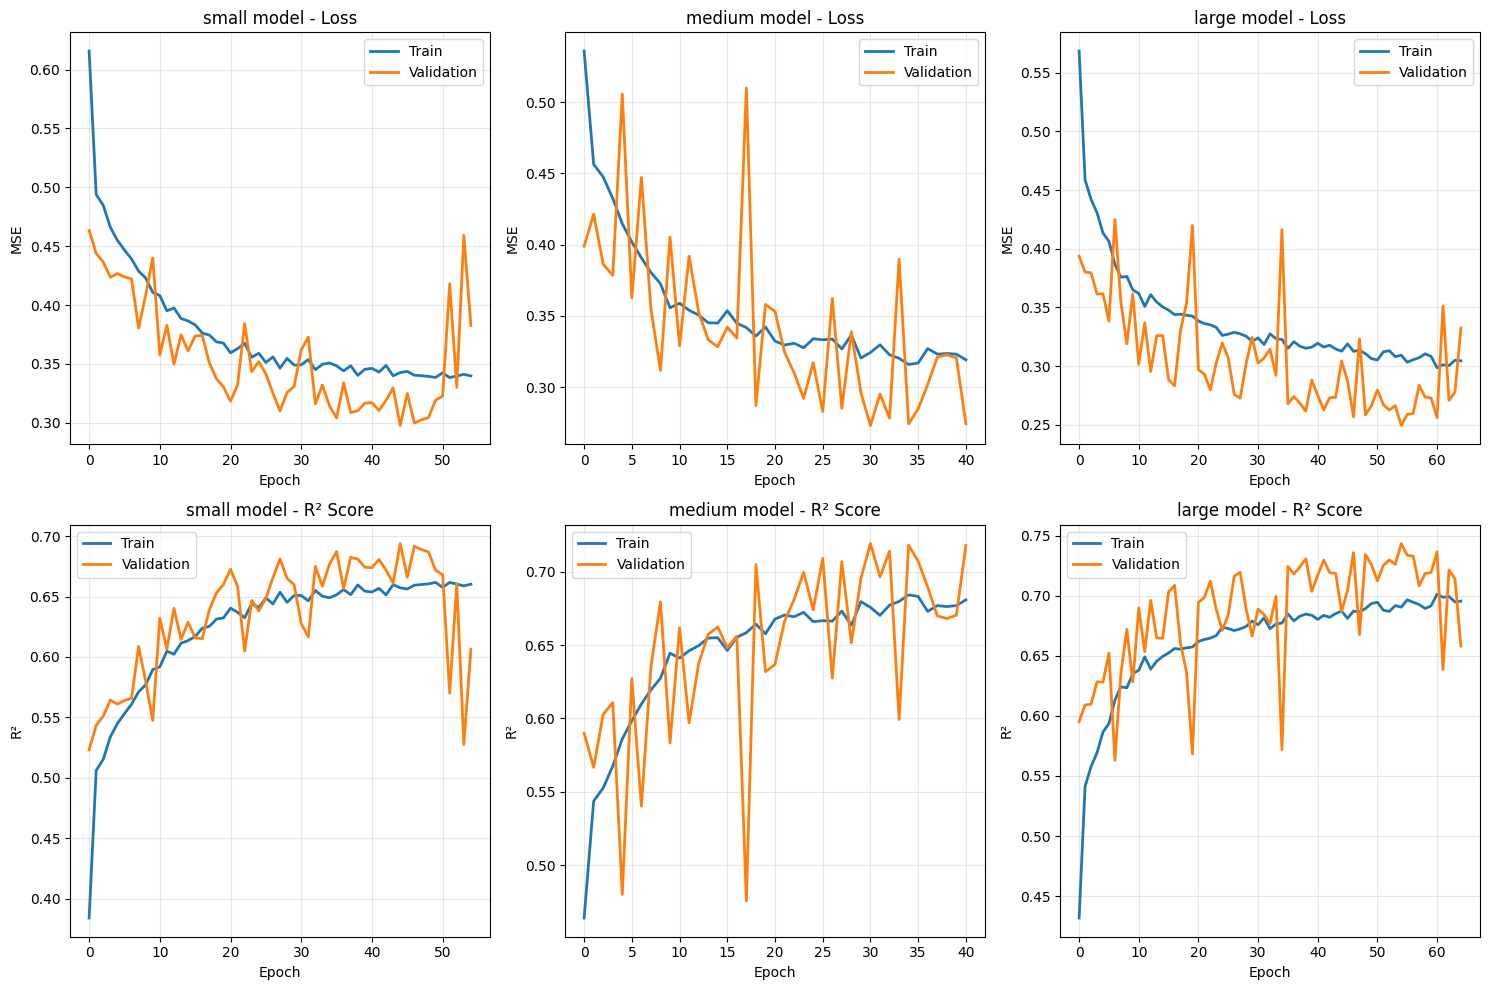

In [31]:
import matplotlib.pyplot as plt

def plot_results(histories, models_config):
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))

    for idx, (name, history) in enumerate(histories.items()):
        axes[0, idx].plot(history['train_loss'], label='Train', linewidth=2)
        axes[0, idx].plot(history['val_loss'], label='Validation', linewidth=2)
        axes[0, idx].set_title(f'{name} model - Loss')
        axes[0, idx].set_xlabel('Epoch')
        axes[0, idx].set_ylabel('MSE')
        axes[0, idx].legend()
        axes[0, idx].grid(True, alpha=0.3)

        axes[1, idx].plot(history['train_r2'], label='Train', linewidth=2)
        axes[1, idx].plot(history['val_r2'], label='Validation', linewidth=2)
        axes[1, idx].set_title(f'{name} model - R² Score')
        axes[1, idx].set_xlabel('Epoch')
        axes[1, idx].set_ylabel('R²')
        axes[1, idx].legend()
        axes[1, idx].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_results(histories, models_config)


Training with ReLU
  Test MSE: 0.267049

Training with LeakyReLU
  Test MSE: 0.299545

Training with ELU
  Test MSE: 0.299467

Training with SoftPlus
  Test MSE: 0.290860


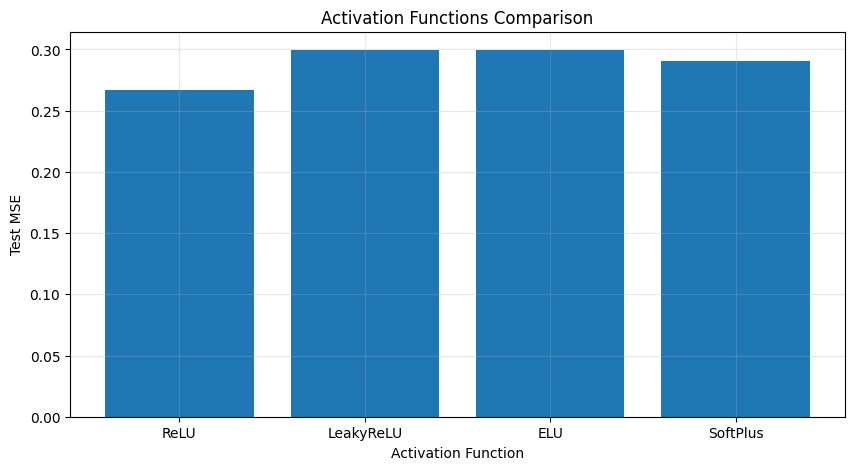

In [32]:
activations = {
    'ReLU': ReLU,
    'LeakyReLU': LeakyReLU,
    'ELU': ELU,
    'SoftPlus': SoftPlus
}

activation_results = {}

for act_name, act_class in activations.items():
    print(f"\nTraining with {act_name}")
    model = create_regression_model([64, 32], activation=act_class, dropout_rate=0.2)
    history = train_model(model, X_train, y_train, X_val, y_val, epochs=100, patience=10)

    model.evaluate()
    test_output = model.forward(X_test)
    test_loss = MSECriterion().forward(test_output, y_test)
    activation_results[act_name] = test_loss
    print(f"  Test MSE: {test_loss:.6f}")

plt.figure(figsize=(10, 5))
names = list(activation_results.keys())
values = list(activation_results.values())
plt.bar(names, values)
plt.xlabel('Activation Function')
plt.ylabel('Test MSE')
plt.title('Activation Functions Comparison')
plt.grid(True, alpha=0.3)
plt.show()

In [33]:
best_model = min(models.items(), key=lambda x: evaluate_model(x[1], X_test, y_test, scaler_y)['mse'])
print(f"\nBest model: {best_model[0]}")
best_results = evaluate_model(best_model[1], X_test, y_test, scaler_y)
print(f"  R²: {best_results['r2']:.4f}")
print(f"  MAE: ${best_results['mae_original']:.2f}K")

best_activation = min(activation_results.items(), key=lambda x: x[1])
print(f"\nBest activation: {best_activation[0]}")
print(f"  Test MSE: {best_activation[1]:.6f}")


Best model: medium
  R²: 0.7394
  MAE: $0.42K

Best activation: ReLU
  Test MSE: 0.267049


### 3. Мультиклассификация на MNIST

In [34]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix
import time
import copy

def get_all_params(model):
    """Собирает все параметры модели в плоский список"""
    params = []
    for p in model.getParameters():
        if isinstance(p, list):
            params.extend(p)
        else:
            params.append(p)
    return params

def get_all_grads(model):
    """Собирает все градиенты модели в плоский список"""
    grads = []
    for g in model.getGradParameters():
        if isinstance(g, list):
            grads.extend(g)
        else:
            grads.append(g)
    return grads

def zero_gradients(model):
    """Обнуляет градиенты всех параметров модели"""
    model.zeroGradParameters()

def accuracy_metric(predictions, targets):
    """Метрика точности для классификации (predictions - log-softmax вывод)"""
    pred_classes = np.argmax(predictions, axis=1)
    true_classes = np.argmax(targets, axis=1)
    return np.mean(pred_classes == true_classes)

In [35]:
class SGD:
    def __init__(self, params, learning_rate=0.01, momentum=0.9, weight_decay=0.0):
        self.params = params
        self.learning_rate = learning_rate
        self.momentum = momentum
        self.weight_decay = weight_decay
        self.velocities = [np.zeros_like(p) for p in params]

    def step(self, grads):
        for i, (param, grad) in enumerate(zip(self.params, grads)):
            if self.weight_decay != 0:
                grad = grad + self.weight_decay * param

            self.velocities[i] = self.momentum * self.velocities[i] - self.learning_rate * grad
            param += self.velocities[i]

class WarmupCosineScheduler:
    def __init__(self, optimizer, warmup_epochs=5, total_epochs=50, base_lr=0.001, min_lr=1e-6):
        self.optimizer = optimizer
        self.warmup_epochs = warmup_epochs
        self.total_epochs = total_epochs
        self.base_lr = base_lr
        self.min_lr = min_lr
        self.current_epoch = 0

    def step(self):
        self.current_epoch += 1

        if self.current_epoch <= self.warmup_epochs:
            lr = self.base_lr * (self.current_epoch / self.warmup_epochs)
        else:
            progress = (self.current_epoch - self.warmup_epochs) / (self.total_epochs - self.warmup_epochs)
            lr = self.min_lr + 0.5 * (self.base_lr - self.min_lr) * (1 + np.cos(np.pi * progress))

        self.optimizer.learning_rate = lr
        return lr

In [36]:
def train_classification_model(model, criterion, optimizer, scheduler,
                                X_train, y_train, X_val, y_val,
                                epochs=20, batch_size=128,
                                patience=7, verbose=True):
    """
    Обучение модели классификации с ранней остановкой и сохранением лучшей модели
    """
    history = {
        'train_loss': [],
        'val_loss': [],
        'train_acc': [],
        'val_acc': [],
        'lr_history': []
    }

    best_val_acc = 0.0
    patience_counter = 0
    best_params = None
    best_epoch = 0

    n_samples = X_train.shape[0]
    n_batches = (n_samples + batch_size - 1) // batch_size

    for epoch in range(epochs):
        current_lr = scheduler.step() if scheduler else optimizer.learning_rate
        history['lr_history'].append(current_lr)

        model.train()
        train_loss = 0.0
        train_acc = 0.0

        indices = np.random.permutation(n_samples)
        X_shuffled = X_train[indices]
        y_shuffled = y_train[indices]

        for batch_idx in range(n_batches):
            start_idx = batch_idx * batch_size
            end_idx = min(start_idx + batch_size, n_samples)

            X_batch = X_shuffled[start_idx:end_idx]
            y_batch = y_shuffled[start_idx:end_idx]

            output = model.forward(X_batch)
            loss = criterion.forward(output, y_batch)

            grad_output = criterion.backward(output, y_batch)
            model.backward(X_batch, grad_output)

            grads = get_all_grads(model)
            optimizer.step(grads)

            batch_acc = accuracy_metric(output, y_batch)
            train_loss += loss * len(X_batch)
            train_acc += batch_acc * len(X_batch)

            zero_gradients(model)

        train_loss /= n_samples
        train_acc /= n_samples

        model.evaluate()
        val_loss = 0.0
        val_acc = 0.0

        n_val_batches = (X_val.shape[0] + batch_size - 1) // batch_size
        for batch_idx in range(n_val_batches):
            start_idx = batch_idx * batch_size
            end_idx = min(start_idx + batch_size, X_val.shape[0])

            X_batch = X_val[start_idx:end_idx]
            y_batch = y_val[start_idx:end_idx]

            output = model.forward(X_batch)
            loss = criterion.forward(output, y_batch)

            val_loss += loss * len(X_batch)
            val_acc += accuracy_metric(output, y_batch) * len(X_batch)

        val_loss /= X_val.shape[0]
        val_acc /= X_val.shape[0]

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        if verbose:
            print(f"Epoch {epoch+1:3d}/{epochs} | LR: {current_lr:.6f} | "
                  f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
                  f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_counter = 0
            best_epoch = epoch + 1
            best_params = [p.copy() for p in get_all_params(model)]
            if verbose:
                print(f"  -> New best model! Val Acc: {val_acc:.4f}")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"\nEarly stopping triggered at epoch {epoch+1}")
                break

    if best_params is not None:
        current_params = get_all_params(model)
        for i, p in enumerate(current_params):
            p[:] = best_params[i]
        print(f"\nRestored best model from epoch {best_epoch} with Val Acc: {best_val_acc:.4f}")

    return history

In [37]:
def plot_training_history(history, title="MNIST Classification"):
    """Визуализация процесса обучения"""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # График loss
    axes[0].plot(history['train_loss'], label='Train Loss', linewidth=2, color='blue')
    axes[0].plot(history['val_loss'], label='Validation Loss', linewidth=2, color='red')
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Loss (NLL)', fontsize=12)
    axes[0].set_title(f'{title} - Loss Curves', fontsize=14)
    axes[0].legend(fontsize=10)
    axes[0].grid(True, alpha=0.3)

    # График accuracy
    axes[1].plot(history['train_acc'], label='Train Accuracy', linewidth=2, color='blue')
    axes[1].plot(history['val_acc'], label='Validation Accuracy', linewidth=2, color='red')
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Accuracy', fontsize=12)
    axes[1].set_title(f'{title} - Accuracy Curves', fontsize=14)
    axes[1].legend(fontsize=10)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def plot_learning_rate(history):
    """График изменения learning rate"""
    plt.figure(figsize=(10, 4))
    plt.plot(history['lr_history'], linewidth=2, color='green')
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Learning Rate', fontsize=12)
    plt.title('Learning Rate Schedule (Warmup + Cosine Annealing)', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.show()

def plot_confusion_matrix(true_classes, pred_classes):
    """Визуализация матрицы ошибок"""
    plt.figure(figsize=(10, 8))
    cm = confusion_matrix(true_classes, pred_classes)
    plt.imshow(cm, interpolation='nearest', cmap='Blues')
    plt.title('Confusion Matrix - MNIST Test Set', fontsize=14)
    plt.colorbar()
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.xticks(range(10), range(10))
    plt.yticks(range(10), range(10))

    for i in range(10):
        for j in range(10):
            plt.text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=8)

    plt.tight_layout()
    plt.show()

In [54]:
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
X, y = mnist['data'], mnist['target']

n_samples_total = 20000
n_test_samples = 4000

indices = np.random.RandomState(42).permutation(X.shape[0])[:n_samples_total]
X = X[indices].astype(np.float32)
y = y[indices].astype(int)

X = X / 255.0

X = X.reshape(-1, 1, 28, 28)

encoder = OneHotEncoder(sparse_output=False)
y_one_hot = encoder.fit_transform(y.reshape(-1, 1))

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y_one_hot, test_size=n_test_samples, random_state=42, shuffle=True
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.2, random_state=42, shuffle=True
)

print(f"Train samples: {X_train.shape[0]}")
print(f"Validation samples: {X_val.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")
print(f"Input shape: {X_train.shape[1:]}")
print(f"Number of classes: {y_one_hot.shape[1]}")

Train samples: 12800
Validation samples: 3200
Test samples: 4000
Input shape: (1, 28, 28)
Number of classes: 10


In [55]:
def build_mnist_cnn(input_channels=1, num_classes=10):
    """
    Строит CNN для классификации MNIST с использованием:
    - Сверточных слоев
    - Batch Normalization
    - MaxPooling
    - Dropout
    - Flatten
    - LogSoftMax на выходе
    """
    model = Sequential()

    model.add(Conv2d(in_channels=input_channels, out_channels=32,
                     kernel_size=3, stride=1, padding=1, bias=False))
    model.add(BatchNormalization())  # alpha=0 по умолчанию, определится автоматически
    model.add(ReLU())
    model.add(MaxPool2d(kernel_size=2, stride=2, padding=0))

    model.add(Conv2d(in_channels=32, out_channels=64,
                     kernel_size=3, stride=1, padding=1, bias=False))
    model.add(BatchNormalization())
    model.add(ReLU())
    model.add(MaxPool2d(kernel_size=2, stride=2, padding=0))

    model.add(Conv2d(in_channels=64, out_channels=128,
                     kernel_size=3, stride=1, padding=1, bias=False))
    model.add(BatchNormalization())
    model.add(ReLU())
    model.add(MaxPool2d(kernel_size=2, stride=2, padding=0))

    model.add(Flatten(start_dim=1))

    model.add(Linear(128 * 3 * 3, 256))  # 128*3*3 = 1152
    model.add(BatchNormalization())
    model.add(ReLU())
    model.add(Dropout(p=0.5))

    model.add(Linear(256, 128))
    model.add(BatchNormalization())
    model.add(ReLU())
    model.add(Dropout(p=0.3))
    model.add(Linear(128, num_classes))
    model.add(LogSoftMax())

    return model

mnist_model = build_mnist_cnn(input_channels=1, num_classes=10)
print(mnist_model)

params_count = sum(p.size for p in get_all_params(mnist_model))

Conv2d(1, 32, kernel_size=3, stride=1, padding=1)
Module
ReLU
MaxPool2d
Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
Module
ReLU
MaxPool2d
Conv2d(64, 128, kernel_size=3, stride=1, padding=1)
Module
ReLU
MaxPool2d
Flatten
Linear 1152 -> 256
Module
ReLU
Dropout
Linear 256 -> 128
Module
ReLU
Dropout
Linear 128 -> 10
LogSoftMax



In [ ]:
print(f"{'Epoch':>6} | {'Train Loss':>10} | {'Val Loss':>10} | {'Train Acc':>9} | {'Val Acc':>9} | {'LR':>10}")
print("-" * 75)

EPOCHS = 30
BATCH_SIZE = 128
LEARNING_RATE = 0.001
WARMUP_EPOCHS = 3
PATIENCE = 7

criterion = ClassNLLCriterion()
params = get_all_params(mnist_model)
optimizer = SGD(params, learning_rate=LEARNING_RATE, momentum=0.9, weight_decay=1e-5)
scheduler = WarmupCosineScheduler(optimizer, warmup_epochs=WARMUP_EPOCHS,
                                   total_epochs=EPOCHS, base_lr=LEARNING_RATE, min_lr=1e-6)

# обучение
history = train_classification_model(
    model=mnist_model,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    patience=PATIENCE,
    verbose=True
)

 Epoch | Train Loss |   Val Loss | Train Acc |   Val Acc |         LR
---------------------------------------------------------------------------


In [ ]:
plot_training_history(history, title="MNIST CNN Classification")
plot_learning_rate(history)
print("\n" + "=" * 60)
print("ОЦЕНКА НА ТЕСТОВОМ НАБОРЕ")
print("=" * 60)

mnist_model.evaluate()

test_predictions = mnist_model.forward(X_test)
test_loss = criterion.forward(test_predictions, y_test)
test_accuracy = accuracy_metric(test_predictions, y_test)

print(f"Test Loss (NLL): {test_loss:.6f}")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

pred_classes = np.argmax(test_predictions, axis=1)
true_classes = np.argmax(y_test, axis=1)

print("\nClassification Report:")
print(classification_report(true_classes, pred_classes, digits=4))

plot_confusion_matrix(true_classes, pred_classes)

In [ ]:
n_examples = 10
indices_to_show = np.random.choice(X_test.shape[0], n_examples, replace=False)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()

for idx, ax in enumerate(axes):
    sample_idx = indices_to_show[idx]
    image = X_test[sample_idx, 0]
    true_label = np.argmax(y_test[sample_idx])
    pred_label = pred_classes[sample_idx]

    ax.imshow(image, cmap='gray')
    color = 'green' if true_label == pred_label else 'red'
    ax.set_title(f'True: {true_label}\nPred: {pred_label}', color=color, fontsize=10)
    ax.axis('off')

plt.suptitle('MNIST Test Samples - Predictions (green=correct, red=wrong)', fontsize=14)
plt.tight_layout()
plt.show()
print(f"Best validation accuracy: {max(history['val_acc']):.4f}")
print(f"Final test accuracy: {test_accuracy:.4f}")

### 4. Автоэнкодер